# Spaceship Titanic: Starter Notebook

**Klab ML course · project assignment**

Your job: predict which passengers were transported to another dimension, get that prediction onto the
Kaggle leaderboard, and then improve it; deliberately, one change at a time.

This notebook takes you to your **first submission**. After that it stops helping and starts asking.
The marks are in what you do next.

### How to use it on Kaggle

1. Go to the competition page and click **Join Competition** (you cannot submit until you do).
2. Click **Code → New Notebook**. The competition data is attached automatically.
3. Copy these cells across, or upload this `.ipynb` with **File → Import Notebook**.
4. Run everything. Then **Submit to Competition** from the notebook's *Output* tab.

### The rule that matters

> Change **one** thing. Re-run the cross-validation. Write down what happened. Only then change the next thing.

Two changes at once and you will never know which one helped.

---
## Part 0 — Setup

In [1]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    print(files)

/kaggle/input
[]
/kaggle/input/competitions
[]
/kaggle/input/competitions/spaceship-titanic
['sample_submission.csv', 'train.csv', 'test.csv']


In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix

SEED = 42          # fix the seed so your experiments are comparable to each other
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 50)

# Kaggle mounts competition data read-only at /kaggle/input/<competition-slug>/.
# The fallback lets the same notebook run on your own machine.
DATA_DIR = Path('/kaggle/input/competitions/spaceship-titanic')
if not DATA_DIR.exists():
    DATA_DIR = Path(os.environ.get('SPACESHIP_DATA', '.'))

print('Reading data from:', DATA_DIR.resolve())
print('Files present:', sorted(p.name for p in DATA_DIR.glob('*.csv')))

Reading data from: /kaggle/input/competitions/spaceship-titanic
Files present: ['sample_submission.csv', 'test.csv', 'train.csv']


In [3]:
train = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/test.csv')

TARGET = 'Transported'
ID = 'PassengerId'

print(f'train: {train.shape[0]:,} rows x {train.shape[1]} columns')
print(f'test : {test.shape[0]:,} rows x {test.shape[1]} columns')
print('\nThe test set has no', TARGET, 'column — that is the bit Kaggle keeps hidden.')
train.head()

train: 8,693 rows x 14 columns
test : 4,277 rows x 13 columns

The test set has no Transported column — that is the bit Kaggle keeps hidden.


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


---
## Part 1: Look at the data before you model it

Skipping this step is the single most common mistake. Ten minutes here will save you three failed
submissions later.

In [4]:
# What type is each column, and how much is missing?
summary = pd.DataFrame({
    'dtype': train.dtypes.astype(str),
    'missing': train.isna().sum(),
    'missing_%': (train.isna().mean() * 100).round(1),
    'unique': train.nunique(),
})
summary

,dtype,missing,missing_%,unique
PassengerId,object,0,0.0,8693
HomePlanet,object,201,2.3,3
CryoSleep,object,217,2.5,2
Cabin,object,199,2.3,6560
Destination,object,182,2.1,3
Age,float64,179,2.1,80
VIP,object,203,2.3,2
RoomService,float64,181,2.1,1273
FoodCourt,float64,183,2.1,1507
ShoppingMall,float64,208,2.4,1115


In [5]:
# How balanced is the target? This sets your floor: if you predicted the majority class
# for everybody, this is the accuracy you would get. Any model must beat it.
balance = train[TARGET].value_counts(normalize=True)
print(balance.round(4))
print(f'\nMajority-class baseline accuracy = {balance.max():.4f}')
print('If your model scores below that, it is worse than a constant.')

Transported
True     0.5036
False    0.4964
Name: proportion, dtype: float64

Majority-class baseline accuracy = 0.5036
If your model scores below that, it is worse than a constant.


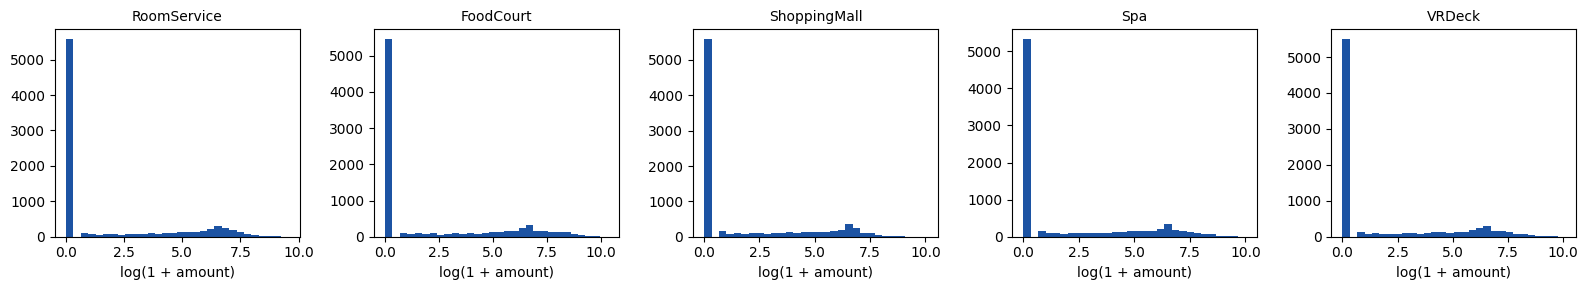

Most passengers spend nothing at all:
RoomService     0.642
FoodCourt       0.628
ShoppingMall    0.643
Spa             0.612
VRDeck          0.632
dtype: float64


In [6]:
# The five spending columns are the heart of this dataset. Look at their shape.
SPEND = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, col in zip(axes, SPEND):
    # log1p because the raw values are extremely skewed: most passengers spend zero
    ax.hist(np.log1p(train[col].dropna()), bins=30, color='#1C53A3')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('log(1 + amount)')
plt.tight_layout(); plt.show()

print('Most passengers spend nothing at all:')
print((train[SPEND] == 0).mean().round(3))

In [7]:
# A single crosstab that tells you most of what you need to know about this problem.
print('Transport rate by CryoSleep:')
print(train.groupby('CryoSleep')[TARGET].agg(['mean', 'count']).round(3))
print('\nTransport rate by HomePlanet:')
print(train.groupby('HomePlanet')[TARGET].agg(['mean', 'count']).round(3))

Transport rate by CryoSleep:
            mean  count
CryoSleep              
False      0.329   5439
True       0.818   3037

Transport rate by HomePlanet:
             mean  count
HomePlanet              
Earth       0.424   4602
Europa      0.659   2131
Mars        0.523   1759


> **Stop and look.** One of those groupings splits the passengers far more sharply than the other.
> That is a hint about which features will carry the model, and about what to engineer in Part 3.

---
## Part 2: A baseline that runs

Resist the urge to be clever. Get *something* scored first, so you know the whole pipeline works —
data in, model trained, file written, leaderboard score out. Then improve it.

### Why a Pipeline, and not just `fillna` on the whole dataframe

If you impute missing values using the mean of the **whole** training set and then cross-validate, each
fold's "validation" rows have already influenced the numbers used to fill them. That is **leakage**, and
it makes your CV score look better than reality. A `Pipeline` fits the imputer inside each fold, on
that fold's training rows only. Use one. The rubric checks for this.

In [8]:
def make_preprocessor(numeric_cols, categorical_cols):
    '''Impute + scale numbers, impute + one-hot encode categories.

    Wrapped in a ColumnTransformer so the whole thing is a single estimator that
    can be fitted inside a cross-validation fold.
    '''
    numeric = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ])
    categorical = Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        # handle_unknown='ignore' stops the model crashing if the test set
        # contains a category the training folds never saw
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', numeric, numeric_cols),
        ('cat', categorical, categorical_cols),
    ])


# The plainest possible feature set: the columns as they arrive, minus the free-text ones.
BASE_NUM = ['Age'] + SPEND
BASE_CAT = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

X_base = train[BASE_NUM + BASE_CAT]
y = train[TARGET].astype(int)      # sklearn wants 0/1, not True/False

baseline = Pipeline([
    ('prep', make_preprocessor(BASE_NUM, BASE_CAT)),
    ('model', LogisticRegression(max_iter=2000, random_state=SEED)),
])
print('Baseline pipeline built.')

Baseline pipeline built.


In [9]:
# StratifiedKFold keeps the class balance the same in every fold, which matters
# whenever the target is not exactly 50/50.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def evaluate(pipeline, X, y, label):
    '''Cross-validate and report mean +/- std. The std is not decoration:
    if two models differ by less than a standard deviation, you have not
    shown that one is better than the other.'''
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f'{label:<34} {scores.mean():.4f}  +/- {scores.std():.4f}')
    return scores.mean(), scores.std()

baseline_score, _ = evaluate(baseline, X_base, y, 'Baseline (raw columns)')
print(f'\nMajority-class floor: {y.value_counts(normalize=True).max():.4f}')

Baseline (raw columns)             0.7860  +/- 0.0096

Majority-class floor: 0.5036


---
## Part 3: Feature engineering

This is where the marks are, and where the score actually moves. Three columns in this dataset are
compressed — they pack several facts into one string — and unpacking them is most of the job.

| Column | What is hiding inside |
|---|---|
| `PassengerId` | `gggg_pp` — the first part is a **travel group**. People travelling together share a fate more often than chance. |
| `Cabin` | `deck/num/side` — three separate facts glued together with slashes. |
| The five spend columns | A total, and the simple fact of *whether they spent anything at all*. |

In [10]:
def engineer(df):
    '''Build the derived features. Takes a raw dataframe, returns a copy with extras.

    Written as a function so that train and test get EXACTLY the same treatment —
    a very common source of bugs is engineering the two sets slightly differently.
    '''
    out = df.copy()

    # ---- PassengerId: gggg_pp -> travel group and position within it
    out['Group'] = out[ID].str.split('_').str[0].astype(int)
    out['GroupPos'] = out[ID].str.split('_').str[1].astype(int)

    # ---- Cabin: deck/num/side -> three usable columns
    cabin = out['Cabin'].str.split('/', expand=True)
    out['Deck'] = cabin[0]
    out['CabinNum'] = pd.to_numeric(cabin[1], errors='coerce')
    out['Side'] = cabin[2]

    # ---- spending: a total, and a plain yes/no
    out['TotalSpend'] = out[SPEND].fillna(0).sum(axis=1)
    out['SpentNothing'] = (out['TotalSpend'] == 0).astype(int)
    # log1p tames the skew you saw in the histograms
    out['LogSpend'] = np.log1p(out['TotalSpend'])

    return out


# Group size has to be computed across train and test TOGETHER: a travel group can
# be split across the two files, and group size is a property of the group, not of
# the split. This is a legitimate use of the test features — we never touch its labels.
combined = pd.concat([engineer(train.drop(columns=[TARGET])), engineer(test)], ignore_index=True)
group_sizes = combined['Group'].value_counts()

train_fe = engineer(train)
test_fe = engineer(test)
for frame in (train_fe, test_fe):
    frame['GroupSize'] = frame['Group'].map(group_sizes)
    frame['IsAlone'] = (frame['GroupSize'] == 1).astype(int)

print('New columns:', [c for c in train_fe.columns if c not in train.columns])
train_fe[['PassengerId', 'Group', 'GroupSize', 'Deck', 'Side', 'TotalSpend', 'SpentNothing']].head()

New columns: ['Group', 'GroupPos', 'Deck', 'CabinNum', 'Side', 'TotalSpend', 'SpentNothing', 'LogSpend', 'GroupSize', 'IsAlone']


,PassengerId,Group,GroupSize,Deck,Side,TotalSpend,SpentNothing
0,0001_01,1,1,B,P,0.0,1
1,0002_01,2,1,F,S,736.0,0
2,0003_01,3,2,A,S,10383.0,0
3,0003_02,3,2,A,S,5176.0,0
4,0004_01,4,1,F,S,1091.0,0


In [11]:
# Do the new features actually separate the classes? Check before you trust them.
for col in ['Deck', 'Side', 'SpentNothing', 'IsAlone']:
    rates = train_fe.groupby(col)[TARGET].agg(['mean', 'count'])
    print(f'--- {col} ---')
    print(rates.round(3).to_string())
    print()

--- Deck ---
       mean  count
Deck              
A     0.496    256
B     0.734    779
C     0.680    747
D     0.433    478
E     0.357    876
F     0.440   2794
G     0.516   2559
T     0.200      5

--- Side ---
       mean  count
Side              
P     0.451   4206
S     0.555   4288

--- SpentNothing ---
               mean  count
SpentNothing              
0             0.299   5040
1             0.786   3653

--- IsAlone ---
          mean  count
IsAlone              
0        0.567   3888
1        0.452   4805



In [12]:

FE_NUM = ['Age', 'CabinNum', 'GroupSize', 'GroupPos',
          'TotalSpend', 'LogSpend', 'SpentNothing',
          'IsAlone'] + SPEND
FE_CAT = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']
X_fe = train_fe[FE_NUM + FE_CAT]
engineered = Pipeline([
    ('prep', make_preprocessor(FE_NUM, FE_CAT)),
    ('model', LogisticRegression(max_iter=2000, random_state=SEED)),
])

fe_score, _ = evaluate(engineered, X_fe, y, 'Same model + engineered features')
print(f'\nChange from baseline: {fe_score - baseline_score:+.4f}')
print('Same model, same settings. Every bit of that difference came from the features.')

Same model + engineered features   0.7921  +/- 0.0059

Change from baseline: +0.0061
Same model, same settings. Every bit of that difference came from the features.


---
## Part 4: Compare model families

Now, and only now, change the model. Same features, same folds, same seed — so that any difference
you see is attributable to the model and nothing else.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

candidates = {
    'Logistic regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random forest': RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient boosting': HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.08,
        random_state=42
    ),
}

results = {}

for name, model in candidates.items():
    pipe = Pipeline([
        ('prep', make_preprocessor(FE_NUM, FE_CAT)),
        ('model', model)
    ])

    scores = cross_val_score(
        pipe,
        X_fe,
        y,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    results[name] = scores.mean()

    print(
        f"{name:<25} "
        f"{scores.mean():.4f} +/- {scores.std():.4f}"
    )

best_name = max(results, key=results.get)

print(f"\nBest so far: {best_name} at {results[best_name]:.4f}")

Logistic regression       0.7921 +/- 0.0059
Random forest             0.8020 +/- 0.0087
Gradient boosting         0.8085 +/- 0.0055

Best so far: Gradient boosting at 0.8085


---
## Part 5: Tune the winner

`GridSearchCV` refits the whole pipeline for every combination, inside every fold, so there is still
no leakage. Start with a small grid: a large one takes a long time and rarely pays for itself.

In [14]:
# This grid tunes the gradient booster, because on small tabular problems it is
# usually the family that wins. If a DIFFERENT model won your Part 4 comparison,
# swap it in here and change the grid keys to match its hyperparameters —
# do not tune a model you did not choose.
tuning_pipe = Pipeline([
    ('prep', make_preprocessor(FE_NUM, FE_CAT)),
    ('model', HistGradientBoostingClassifier(random_state=SEED)),
])

# 'model__' prefixes reach inside the pipeline step named 'model'
grid = {
    'model__learning_rate': [0.05, 0.1],
    'model__max_iter': [200, 400],
    'model__max_leaf_nodes': [15, 31],
}

search = GridSearchCV(tuning_pipe, grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=0)
search.fit(X_fe, y)

print('Best parameters:', search.best_params_)
print(f'Best CV accuracy: {search.best_score_:.4f}')

top = pd.DataFrame(search.cv_results_)[
    ['params', 'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False).head(5)
print('\nTop 5 combinations:')
print(top.to_string(index=False))

Best parameters: {'model__learning_rate': 0.05, 'model__max_iter': 200, 'model__max_leaf_nodes': 15}
Best CV accuracy: 0.8123

Top 5 combinations:
                                                                             params  mean_test_score  std_test_score
{'model__learning_rate': 0.05, 'model__max_iter': 200, 'model__max_leaf_nodes': 15}         0.812263        0.003933
 {'model__learning_rate': 0.1, 'model__max_iter': 400, 'model__max_leaf_nodes': 15}         0.811688        0.006560
{'model__learning_rate': 0.05, 'model__max_iter': 400, 'model__max_leaf_nodes': 15}         0.811457        0.005966
 {'model__learning_rate': 0.1, 'model__max_iter': 200, 'model__max_leaf_nodes': 15}         0.811113        0.007995
{'model__learning_rate': 0.05, 'model__max_iter': 200, 'model__max_leaf_nodes': 31}         0.810882        0.005729


---
## Part 6: Look at what the model got wrong

An accuracy number tells you how often you were right. It does not tell you *where* you were wrong,
which is the part you can act on.

In [15]:
from sklearn.model_selection import cross_val_predict

best_model = search.best_estimator_
oof = cross_val_predict(best_model, X_fe, y, cv=cv, n_jobs=-1)   # out-of-fold predictions

cm = confusion_matrix(y, oof)
print('Confusion matrix (rows = truth, columns = prediction)')
print(pd.DataFrame(cm,
                   index=['actually not transported', 'actually transported'],
                   columns=['predicted not', 'predicted yes']).to_string())
print(f'\nOut-of-fold accuracy: {accuracy_score(y, oof):.4f}')

# Where do the mistakes concentrate? Slice the errors by a feature and look.
errors = train_fe.assign(correct=(oof == y))
print('\nAccuracy by deck:')
print(errors.groupby('Deck')['correct'].agg(['mean', 'count']).round(3).to_string())
print('\nAccuracy by CryoSleep:')
print(errors.groupby('CryoSleep')['correct'].agg(['mean', 'count']).round(3).to_string())

Confusion matrix (rows = truth, columns = prediction)
                          predicted not  predicted yes
actually not transported           3425            890
actually transported                742           3636

Out-of-fold accuracy: 0.8123

Accuracy by deck:
       mean  count
Deck              
A     0.836    256
B     0.949    779
C     0.934    747
D     0.860    478
E     0.779    876
F     0.835   2794
G     0.712   2559
T     1.000      5

Accuracy by CryoSleep:
            mean  count
CryoSleep              
False      0.809   5439
True       0.818   3037


> **This is the cell that generates your next experiment.** Find the slice where accuracy is worst,
> then ask what feature would help the model tell those passengers apart. That question — not a
> hyperparameter sweep is what moves a score from 0.79 to 0.81.

---
## Part 7: Make the submission file

Kaggle wants a CSV with exactly two columns: `PassengerId` and `Transported`, with `Transported` as
`True`/`False` — **not** 1/0, and not probabilities.

In [16]:
# Refit the chosen pipeline on ALL the training data. Cross-validation was for
# choosing; now that the choice is made, use every row you have.
final_model = search.best_estimator_
final_model.fit(X_fe, y)

X_test = test_fe[FE_NUM + FE_CAT]
predictions = final_model.predict(X_test)

submission = pd.DataFrame({
    ID: test_fe[ID],
    TARGET: predictions.astype(bool),     # back to True/False for Kaggle
})
submission.to_csv('submission.csv', index=False)

print(submission.shape)
print(submission[TARGET].value_counts(normalize=True).round(3))
submission.head()

(4277, 2)
Transported
True     0.526
False    0.474
Name: proportion, dtype: float64


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


### Submitting

On Kaggle, run the notebook with **Save Version → Save & Run All**. When it finishes, open the version,
go to the **Output** tab, find `submission.csv` and click **Submit to Competition**.

Then write the score in your log — **next to the CV score you got in this notebook**. The gap between
those two numbers is information. A large gap usually means you tuned against the leaderboard, or your
folds leak.

---
## Part 8: Your turn

The notebook stops helping here. Everything below is yours to do, and it is what is being marked.

### Your iteration log

Copy this table into your write-up and add a row for every submission. Five rows minimum.

| # | What I changed | Why I expected it to help | CV score | Leaderboard | What I concluded |
|---|---|---|---|---|---|
| 1 | Baseline, raw columns | Prove the pipeline works | | | |
| 2 | Added engineered features | Cabin and group structure look predictive | | | |
| 3 | | | | | |
| 4 | | | | | |
| 5 | | | | | |

### Experiment 1: Group leakage, the good kind

Passengers in the same travel group tend to share an outcome. You already computed `GroupSize`. Now
build a feature capturing **how many of a passenger's group-mates were transported**, using only the
training rows.

Careful: for a training passenger, that feature must exclude *their own* label, or you leak the answer
into the model and your CV score will be beautiful and meaningless. Compute the group sum, subtract
the passenger's own value, divide by (group size − 1).

- Does CV improve?
- Does the leaderboard improve by the same amount? If not, why might that be?

### Experiment 2: Missing values as a signal

You imputed missing values away. But *being missing* can itself be informative — a passenger with no
`Cabin` recorded may differ systematically from one who has it.

Add a binary "was missing" indicator for the three or four columns with the most missing values
(`SimpleImputer(add_indicator=True)` does this for you). Does it help?

### Experiment 3: Spending as a fingerprint

`TotalSpend` throws away *which* amenities a passenger used. Try instead:

- the number of amenities with non-zero spend
- the single largest spend category as a categorical feature
- each spend column log-transformed individually

Which of the three helps most? Change one at a time.

### Experiment 4: Beat the tuning

Kaggle has `xgboost`, `lightgbm` and `catboost` pre-installed. Try one. CatBoost in particular handles
categorical columns natively, so it may not need your one-hot encoding at all.

Does it beat your tuned `HistGradientBoostingClassifier`? By more than one standard deviation?

### Experiment 5: Blend

Average the predicted probabilities of your best two or three different models (use `predict_proba`
and threshold at 0.5). Ensembles usually beat their members because their mistakes are not identical.

- Does the blend beat the best single model?
- Is the improvement larger than the fold-to-fold standard deviation?

---

### Before you submit the assignment

- [ ] The notebook runs top to bottom on a fresh Kaggle session with no errors
- [ ] At least one submission is scored on the leaderboard
- [ ] The iteration log has five or more completed rows, each with CV *and* leaderboard scores
- [ ] At least three engineered features, each justified by something you actually saw in the data
- [ ] You can explain one change that made the score **worse**, and why you think it did

That last one is not a joke. An experiment that fails and is understood is worth more marks here than
one that succeeds by accident.

In [ ]:
# Three checks worth running every single time, before you spend a submission.
problems = []
if len(submission) != len(test):
    problems.append(f'row count {len(submission)} != test rows {len(test)}')
if list(submission.columns) != [ID, TARGET]:
    problems.append(f'columns are {list(submission.columns)}, expected [{ID}, {TARGET}]')
if submission[TARGET].dtype != bool:
    problems.append(f'{TARGET} is {submission[TARGET].dtype}, expected bool')
if submission[ID].duplicated().any():
    problems.append('duplicate PassengerIds')
if submission.isna().any().any():
    problems.append('the file contains missing values')

print('PROBLEMS: ' + '; '.join(problems) if problems else 'All checks passed — ready to submit.')